# Analisis Hubungan Tegangan Input vs Pressure Pompa Air

**Sumber data:** `5 juni 2026_PERCOBAAN1.csv`  
**Kondisi:** 4 keran, bukaan setengah, `duty_percent >= 60`, `valve_phase = stable`

## 1. Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# Plot style
plt.rcParams["figure.figsize"] = (14, 10)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 12
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Load data
DATA_DIR = r"E:\SEMESTER 8\TA\BUKU TA_YOEL"
df_raw = pd.read_csv(DATA_DIR + "\\5 juni 2026_PERCOBAAN1.csv")
print(f"Total data mentah: {len(df_raw)} baris")
df_raw.head()

Total data mentah: 624 baris


,pc_timestamp,stm32_ms,adc_raw,adc_voltage_v,sensor_voltage_v,pressure_bar,duty_percent,frequency_hz,estimated_output_rms_v,jsy_online,jsy_voltage_rms_v,jsy_current_rms_a,jsy_active_power_w,jsy_power_factor,jsy_energy_kwh,jsy_error_count,valve_open_count,valve_state_label,valve_phase
0,2026-06-05T22:13:02.724,4582538,410,0.340667,0.497333,0.013000,50,5000,110,1,110.86,0.640,67,0.944,0.0,3426,-,Belum ditandai,unset
1,2026-06-05T22:13:03.235,4583060,421,0.340600,0.497067,0.012733,50,5000,110,1,110.87,0.642,67,0.941,0.0,3426,-,Belum ditandai,unset
2,2026-06-05T22:13:03.750,4583585,424,0.339467,0.496333,0.012867,50,5000,110,1,110.87,0.642,67,0.941,0.0,3426,-,Belum ditandai,unset
3,2026-06-05T22:13:04.294,4584147,425,0.339267,0.496400,0.011600,50,5000,110,1,110.87,0.643,67,0.939,0.0,3426,-,Belum ditandai,unset
4,2026-06-05T22:13:04.872,4584672,427,0.340133,0.496600,0.011333,50,5000,110,1,110.87,0.643,67,0.939,0.0,3426,-,Belum ditandai,unset


## 2. Filter Data Sesuai Metadata

In [2]:
# Filter: duty_percent >= 60 dan valve_phase = stable
df = df_raw[(df_raw["duty_percent"] >= 60) & (df_raw["valve_phase"] == "stable")].copy()
print(f"Data setelah filter: {len(df)} baris")
print(f"Duty unik: {sorted(df['duty_percent'].unique())}")
print(f"\nDistribusi duty_percent:")
print(df["duty_percent"].value_counts().sort_index())

# Pilih kolom tegangan: jsy_voltage_rms_v (tegangan output RMS dari sensor JSY)
# Kolom pressure: pressure_bar
print(f"\nRange tegangan (jsy_voltage_rms_v): {df['jsy_voltage_rms_v'].min():.2f} - {df['jsy_voltage_rms_v'].max():.2f} V")
print(f"Range pressure: {df['pressure_bar'].min():.4f} - {df['pressure_bar'].max():.4f} bar")
print(f"Range duty cycle: {df['duty_percent'].min()}% - {df['duty_percent'].max()}%")

Data setelah filter: 376 baris
Duty unik: [60, 70, 80, 90, 95]

Distribusi duty_percent:
duty_percent
60    72
70    84
80    65
90    74
95    81
Name: count, dtype: int64

Range tegangan (jsy_voltage_rms_v): 130.79 - 203.19 V
Range pressure: 0.0094 - 0.9448 bar
Range duty cycle: 60% - 95%


## 3. Scatter Plot: Tegangan vs Pressure (Semua Duty)

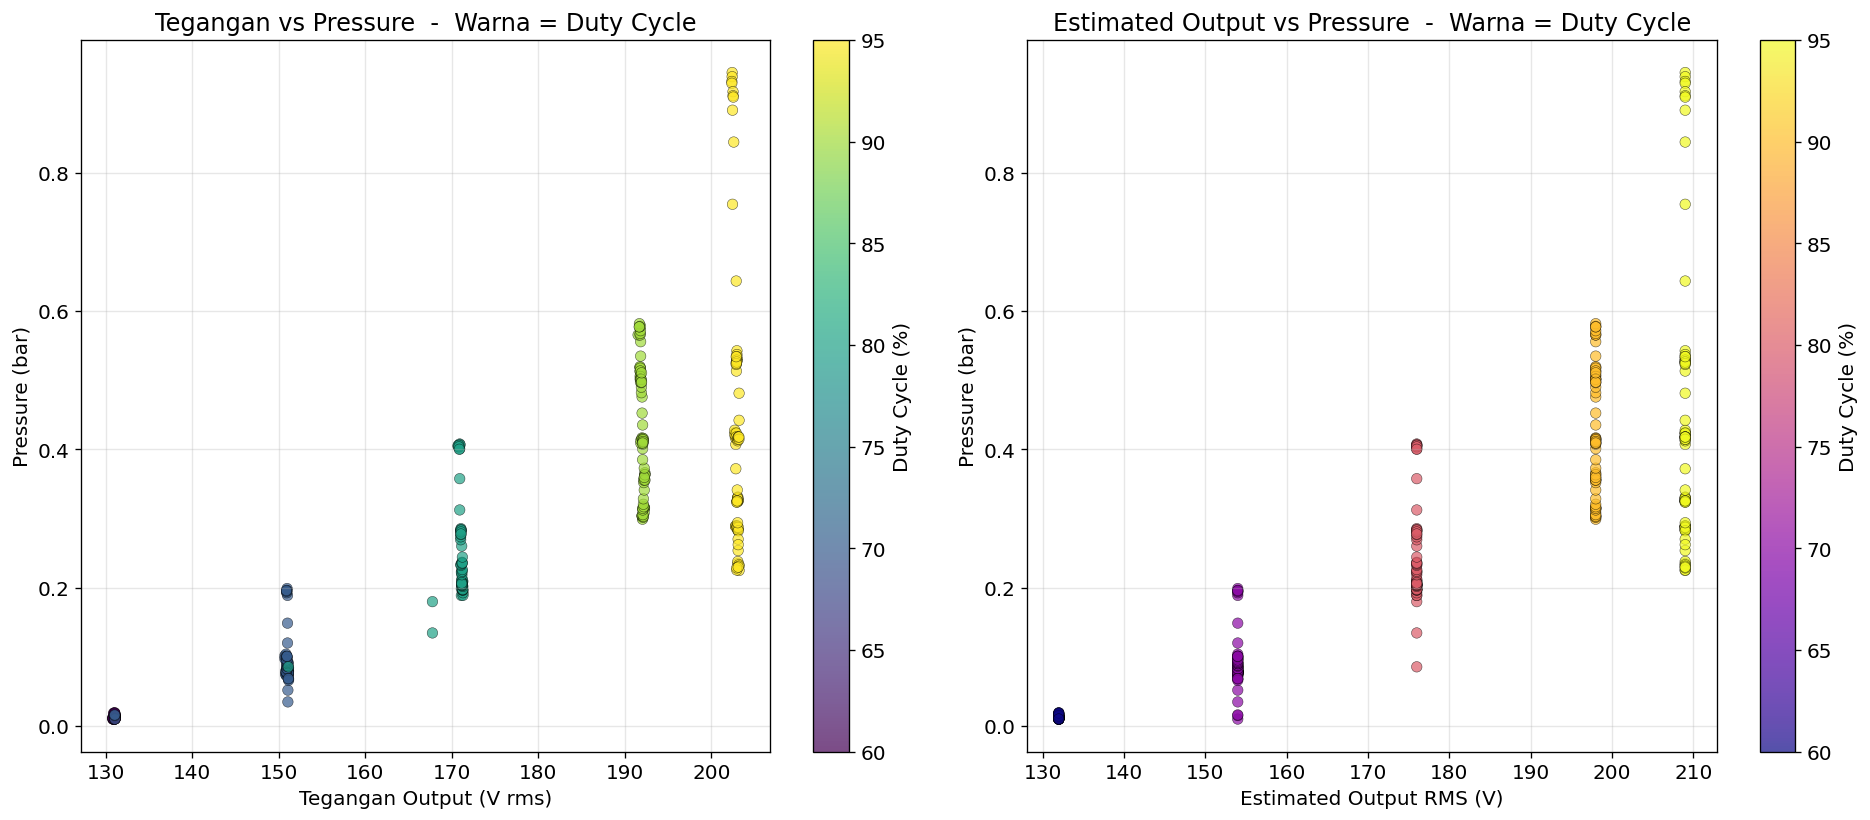

Gambar disimpan di: analisis/scatter_tegangan_vs_pressure.png


In [3]:
# Plot semua data
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Subplot 1: Warna berdasarkan duty
ax = axes[0]
sc = ax.scatter(df["jsy_voltage_rms_v"], df["pressure_bar"],
                c=df["duty_percent"], cmap="viridis", s=40, alpha=0.7, edgecolors="k", linewidth=0.3)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Duty Cycle (%)")
ax.set_xlabel("Tegangan Output (V rms)")
ax.set_ylabel("Pressure (bar)")
ax.set_title("Tegangan vs Pressure  -  Warna = Duty Cycle")

# Subplot 2: estimated_output_rms_v vs pressure
ax = axes[1]
sc = ax.scatter(df["estimated_output_rms_v"], df["pressure_bar"],
                c=df["duty_percent"], cmap="plasma", s=40, alpha=0.7, edgecolors="k", linewidth=0.3)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Duty Cycle (%)")
ax.set_xlabel("Estimated Output RMS (V)")
ax.set_ylabel("Pressure (bar)")
ax.set_title("Estimated Output vs Pressure  -  Warna = Duty Cycle")

plt.tight_layout()
plt.savefig(DATA_DIR + "\\analisis\\scatter_tegangan_vs_pressure.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gambar disimpan di: analisis/scatter_tegangan_vs_pressure.png")

## 4. Analisis Per Duty Cycle

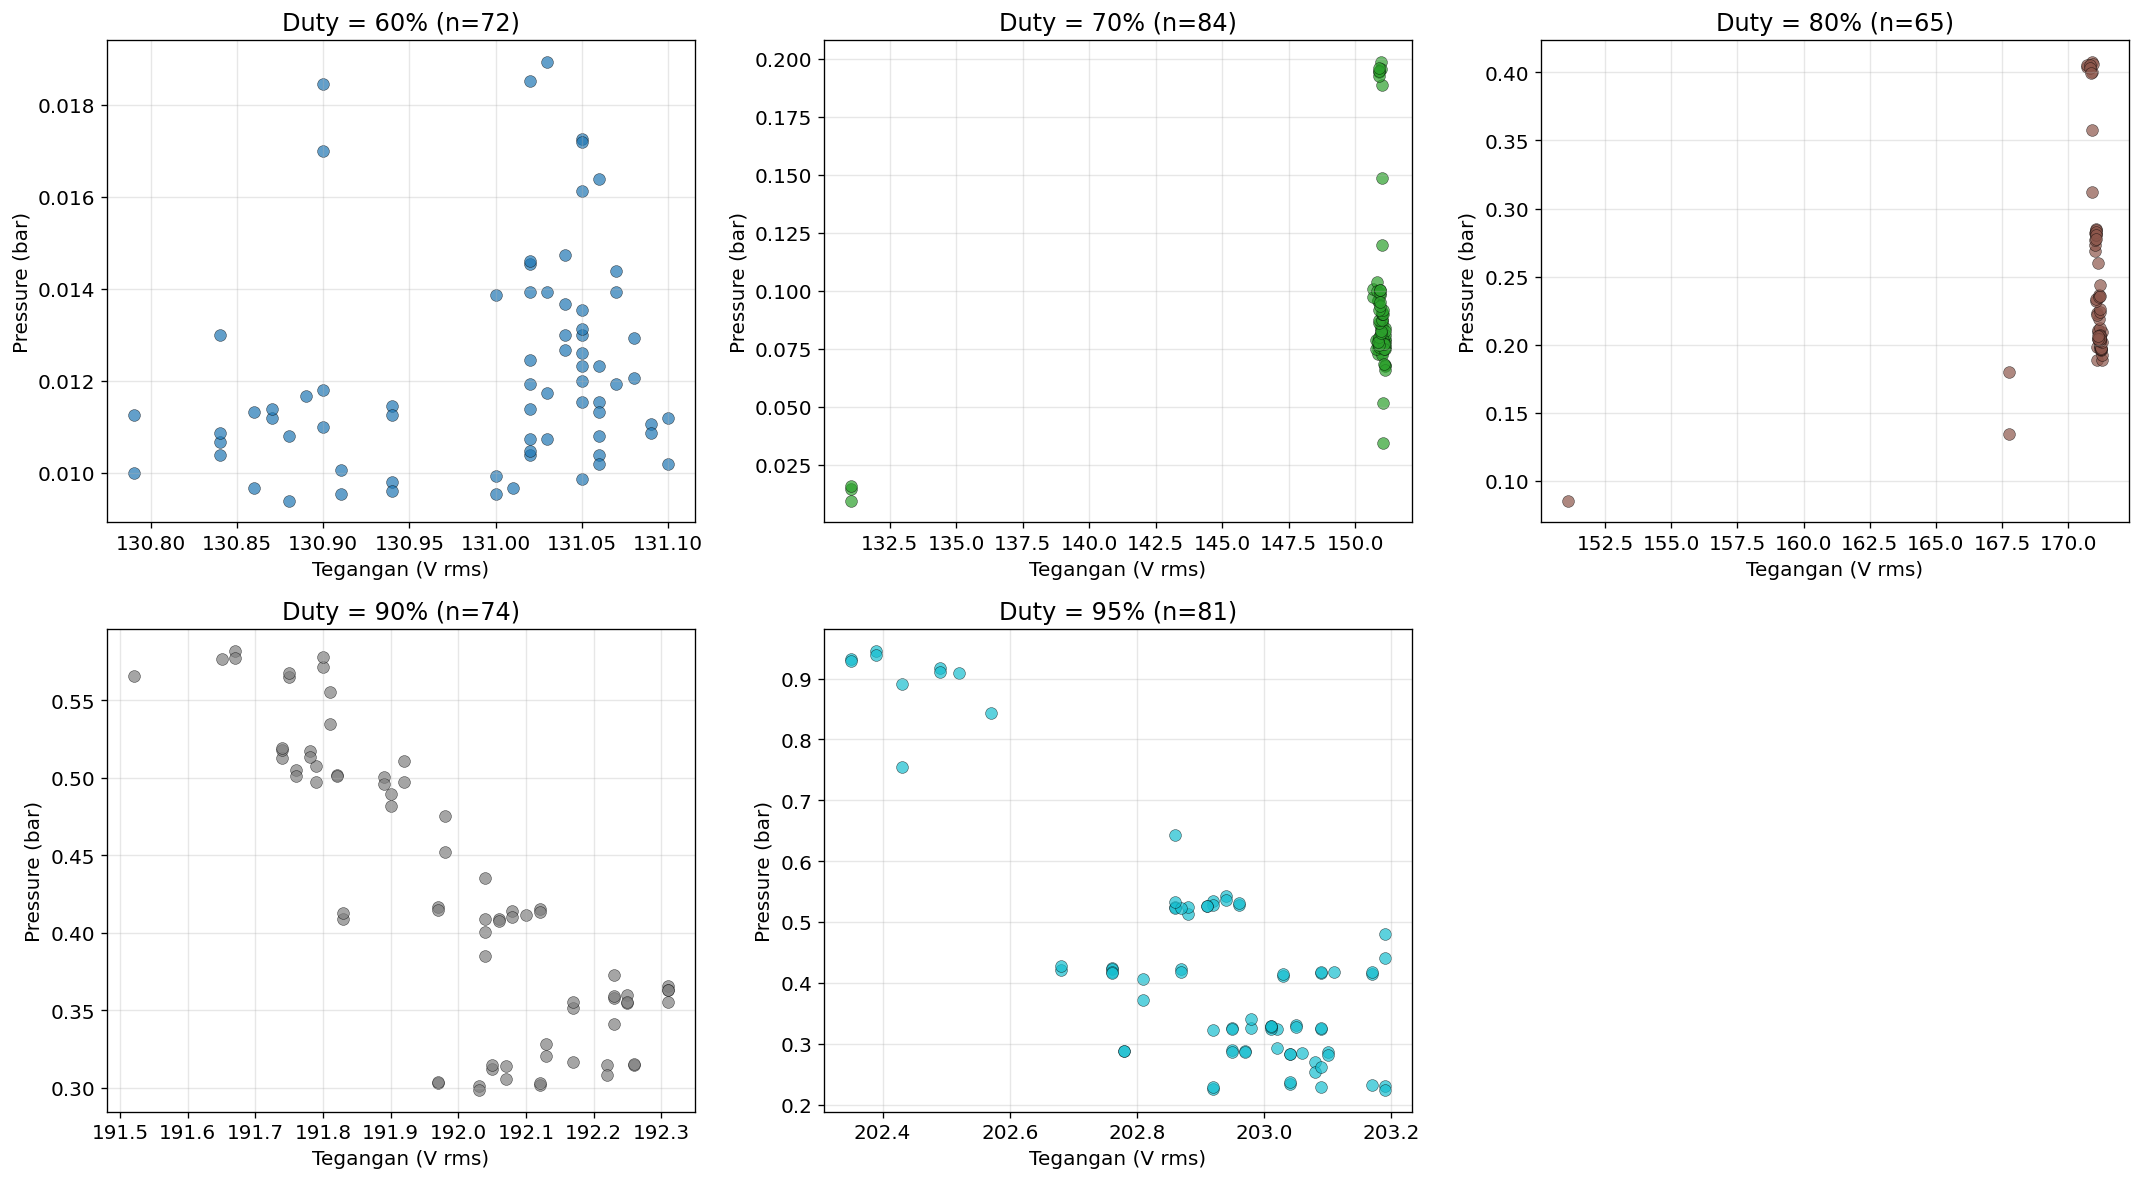


=== Tabel Ringkasan Per Duty ===
 duty  n   V_mean  V_std  P_mean  P_std  V_min  V_max  P_min  P_max
   60 72 130.9922 0.0840  0.0123 0.0023 130.79 131.10 0.0094 0.0189
   70 84 150.2520 3.7215  0.0901 0.0367 131.03 151.12 0.0097 0.1985
   80 65 170.6906 2.5407  0.2452 0.0723 151.09 171.28 0.0853 0.4076
   90 74 191.9950 0.1951  0.4226 0.0909 191.52 192.31 0.2988 0.5816
   95 81 202.9069 0.2136  0.4402 0.1997 202.35 203.19 0.2247 0.9448


In [4]:
# Plot per duty cycle
duties = sorted(df["duty_percent"].unique())
n = len(duties)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

colors = plt.cm.tab10(np.linspace(0, 1, n))
summary_stats = []

for i, duty in enumerate(duties):
    sub = df[df["duty_percent"] == duty]
    ax = axes[i]
    ax.scatter(sub["jsy_voltage_rms_v"], sub["pressure_bar"],
              c=colors[i], s=50, alpha=0.7, edgecolors="k", linewidth=0.3)
    ax.set_title(f"Duty = {duty}% (n={len(sub)})")
    ax.set_xlabel("Tegangan (V rms)")
    ax.set_ylabel("Pressure (bar)")
    
    stats = {
        "duty": duty, "n": len(sub),
        "V_mean": sub["jsy_voltage_rms_v"].mean(),
        "V_std": sub["jsy_voltage_rms_v"].std(),
        "P_mean": sub["pressure_bar"].mean(),
        "P_std": sub["pressure_bar"].std(),
        "V_min": sub["jsy_voltage_rms_v"].min(),
        "V_max": sub["jsy_voltage_rms_v"].max(),
        "P_min": sub["pressure_bar"].min(),
        "P_max": sub["pressure_bar"].max(),
    }
    summary_stats.append(stats)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(DATA_DIR + "\\analisis\\scatter_per_duty.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabel summary
df_stats = pd.DataFrame(summary_stats)
df_stats = df_stats.round(4)
print("\n=== Tabel Ringkasan Per Duty ===")
print(df_stats.to_string(index=False))

## 5. Analisis Regresi: Apakah Hubungan Linear, Eksponensial, atau Polinomial?

In [5]:
# Definisi fungsi untuk regresi
def linear(x, a, b):
    return a * x + b

def exponential(x, a, b, c):
    return a * np.exp(b * x) + c

def power_law(x, a, b, c):
    return a * x**b + c

def quadratic(x, a, b, c):
    return a * x**2 + b * x + c

def cubic(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

# Gunakan jsy_voltage_rms_v sebagai tegangan input
X_full = df["jsy_voltage_rms_v"].values
y_full = df["pressure_bar"].values

# --- Fit semua model ---
models = {}
results = []

# 1. Linear
p_lin, _ = curve_fit(linear, X_full, y_full, maxfev=10000)
y_pred_lin = linear(X_full, *p_lin)
r2_lin = r2_score(y_full, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_full, y_pred_lin))
models["Linear"] = (p_lin, y_pred_lin)
results.append({"Model": "Linear: P = a*V + b", "R2": r2_lin, "RMSE": rmse_lin, "Params": f"a={p_lin[0]:.6f}, b={p_lin[1]:.6f}"})

# 2. Quadratic
p_quad, _ = curve_fit(quadratic, X_full, y_full, maxfev=10000)
y_pred_quad = quadratic(X_full, *p_quad)
r2_quad = r2_score(y_full, y_pred_quad)
rmse_quad = np.sqrt(mean_squared_error(y_full, y_pred_quad))
models["Quadratic"] = (p_quad, y_pred_quad)
results.append({"Model": "Quadratic: P = a*V^2 + b*V + c", "R2": r2_quad, "RMSE": rmse_quad, "Params": f"a={p_quad[0]:.6f}, b={p_quad[1]:.6f}, c={p_quad[2]:.6f}"})

# 3. Cubic
try:
    p_cub, _ = curve_fit(cubic, X_full, y_full, maxfev=10000)
    y_pred_cub = cubic(X_full, *p_cub)
    r2_cub = r2_score(y_full, y_pred_cub)
    rmse_cub = np.sqrt(mean_squared_error(y_full, y_pred_cub))
    models["Cubic"] = (p_cub, y_pred_cub)
    results.append({"Model": "Cubic: P = a*V^3 + b*V^2 + c*V + d", "R2": r2_cub, "RMSE": rmse_cub, "Params": f"a={p_cub[0]:.6f}, b={p_cub[1]:.6f}, c={p_cub[2]:.6f}, d={p_cub[3]:.6f}"})
except Exception as e:
    print(f"Cubic gagal: {e}")

# 4. Eksponensial
try:
    p_exp, _ = curve_fit(exponential, X_full, y_full, p0=[0.001, 0.02, 0.1], maxfev=10000)
    y_pred_exp = exponential(X_full, *p_exp)
    r2_exp = r2_score(y_full, y_pred_exp)
    rmse_exp = np.sqrt(mean_squared_error(y_full, y_pred_exp))
    models["Eksponensial"] = (p_exp, y_pred_exp)
    results.append({"Model": "Eksponensial: P = a*e^(b*V) + c", "R2": r2_exp, "RMSE": rmse_exp, "Params": f"a={p_exp[0]:.6f}, b={p_exp[1]:.6f}, c={p_exp[2]:.6f}"})
except Exception as e:
    print(f"Eksponensial gagal: {e}")
    r2_exp = -np.inf

# 5. Power law
try:
    p_pow, _ = curve_fit(power_law, X_full, y_full, p0=[0.001, 1.5, 0.01], maxfev=10000)
    y_pred_pow = power_law(X_full, *p_pow)
    r2_pow = r2_score(y_full, y_pred_pow)
    rmse_pow = np.sqrt(mean_squared_error(y_full, y_pred_pow))
    models["Power Law"] = (p_pow, y_pred_pow)
    results.append({"Model": "Power: P = a*V^b + c", "R2": r2_pow, "RMSE": rmse_pow, "Params": f"a={p_pow[0]:.6f}, b={p_pow[1]:.6f}, c={p_pow[2]:.6f}"})
except Exception as e:
    print(f"Power law gagal: {e}")

# Hasil perbandingan
df_results = pd.DataFrame(results).sort_values("R2", ascending=False)
print("=== PERBANDINGAN MODEL REGRESI ===")
print(df_results.to_string(index=False))

=== PERBANDINGAN MODEL REGRESI ===
                             Model       R2     RMSE                                            Params
Cubic: P = a*V^3 + b*V^2 + c*V + d 0.728931 0.105963 a=-0.000003, b=0.001327, c=-0.212652, d=11.042749
              Power: P = a*V^b + c 0.713921 0.108858               a=0.000508, b=1.426958, c=-0.534571
    Quadratic: P = a*V^2 + b*V + c 0.713815 0.108878               a=0.000008, b=0.003750, c=-0.630527
   Eksponensial: P = a*e^(b*V) + c 0.713750 0.108890               a=2.143040, b=0.002110, c=-2.827490
               Linear: P = a*V + b 0.713397 0.108957                           a=0.006446, b=-0.850790


## 6. Visualisasi Hasil Regresi

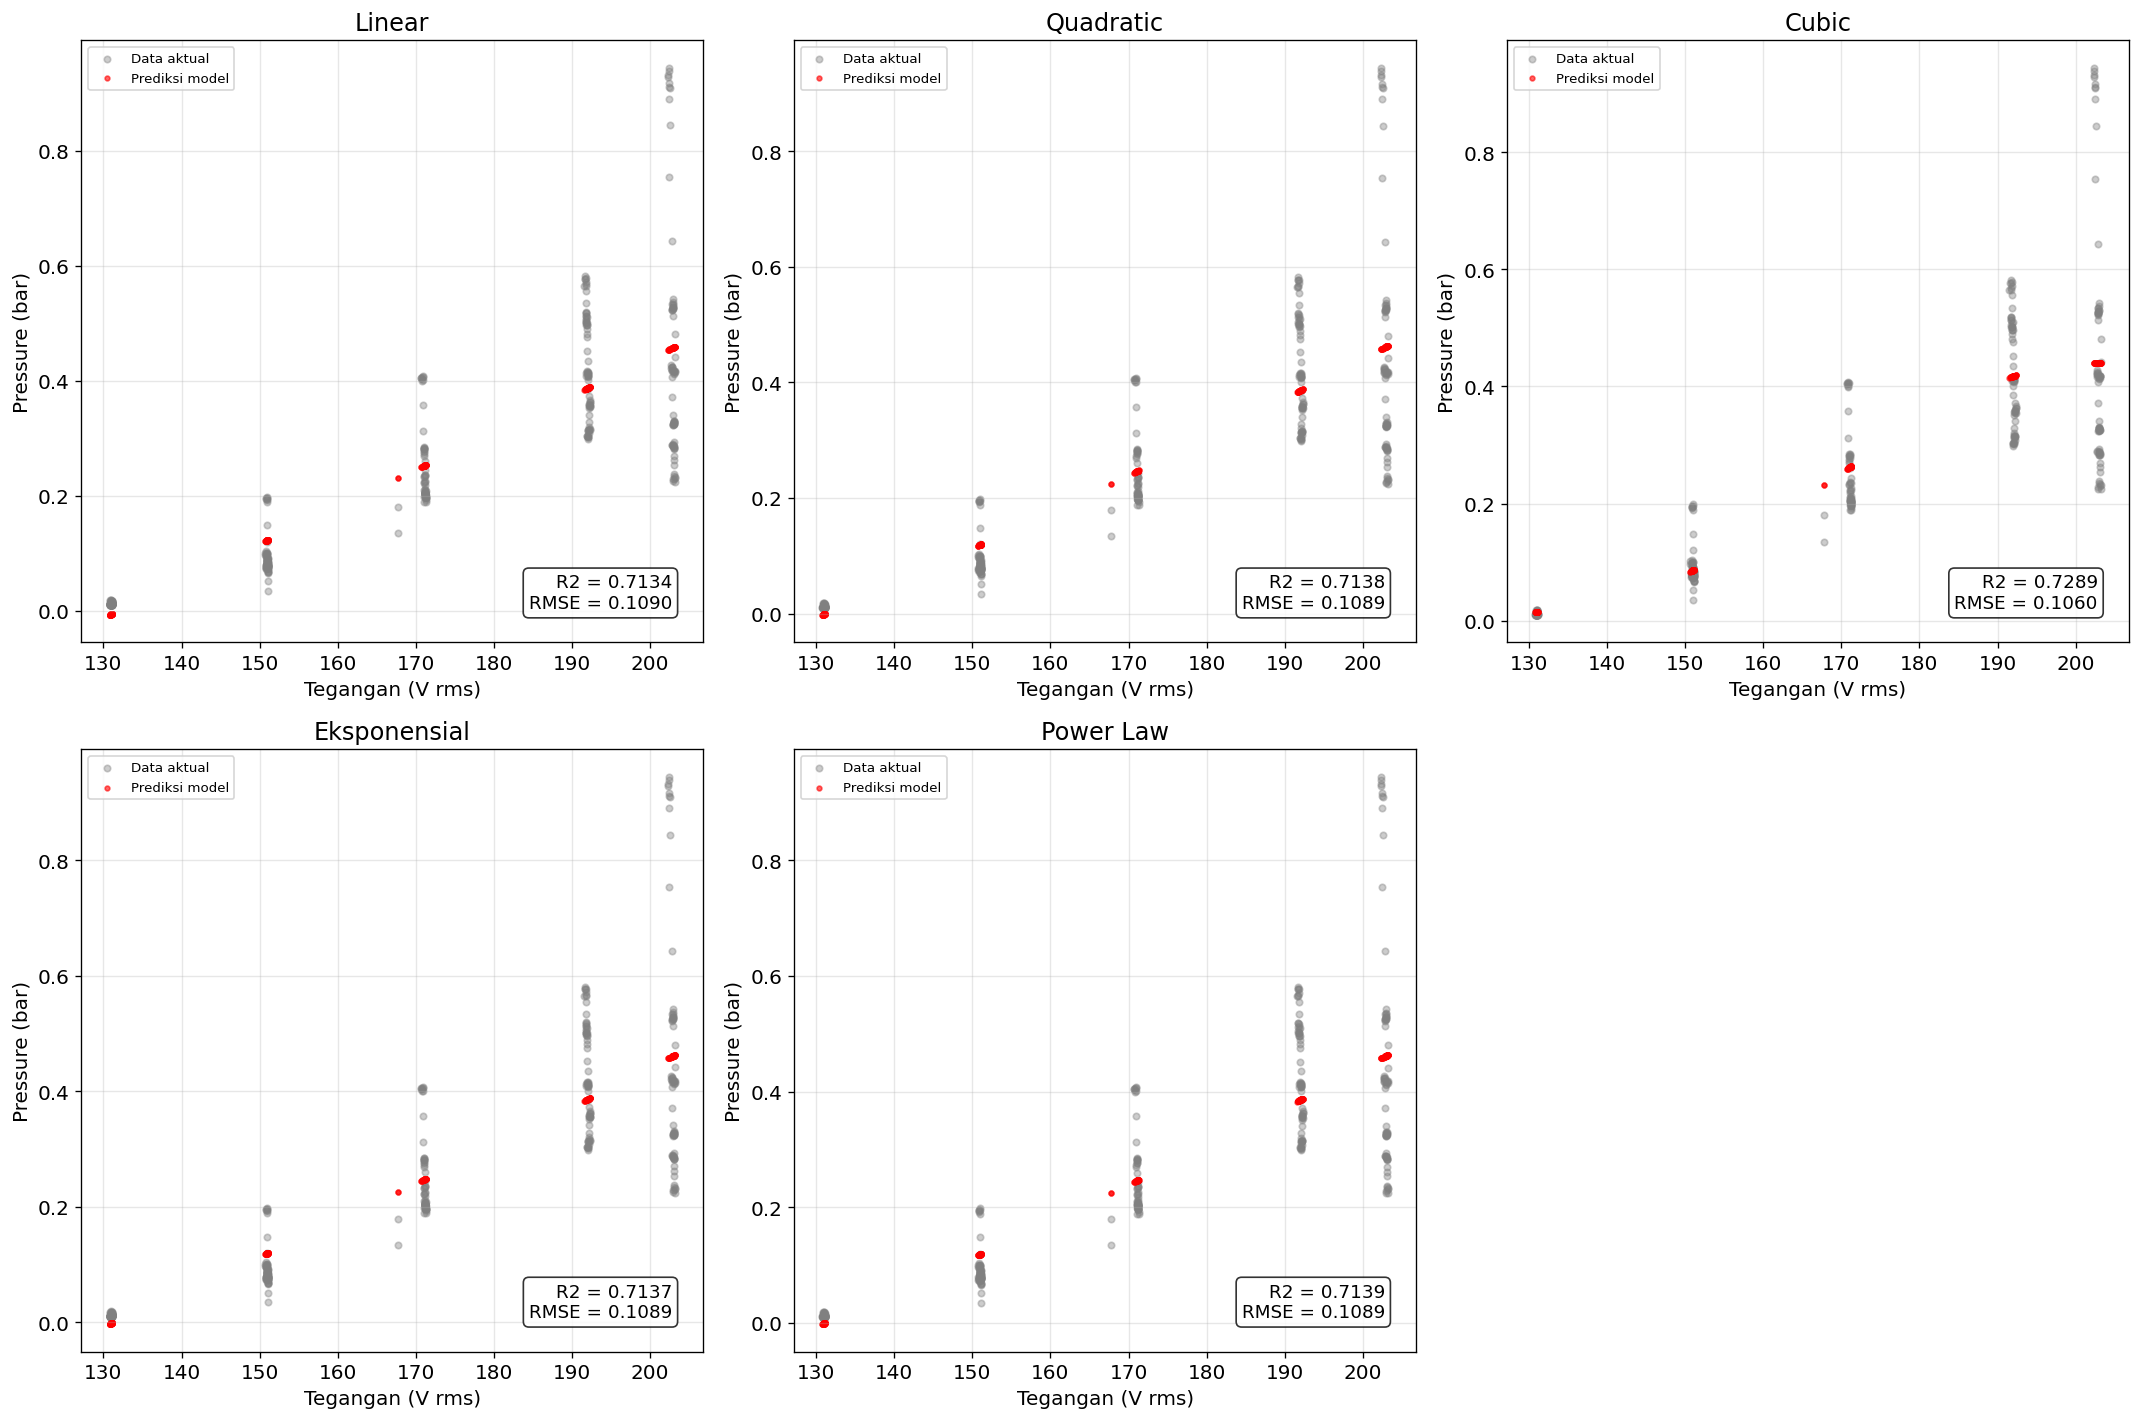

Gambar disimpan di: analisis/regression_comparison.png


In [6]:
# Plot perbandingan model
model_names = list(models.keys())
n_models = len(model_names)
cols2 = 3
rows2 = (n_models + cols2 - 1) // cols2

fig, axes = plt.subplots(rows2, cols2, figsize=(18, 6 * rows2))
axes = axes.flatten()

X_smooth = np.linspace(X_full.min(), X_full.max(), 300)

for i, name in enumerate(model_names):
    ax = axes[i]
    p, y_pred = models[name]
    ax.scatter(X_full, y_full, s=15, alpha=0.4, c="gray", label="Data aktual")
    ax.scatter(X_full, y_pred, s=8, alpha=0.6, c="red", label="Prediksi model")
    ax.set_xlabel("Tegangan (V rms)")
    ax.set_ylabel("Pressure (bar)")
    ax.set_title(name)
    ax.legend(loc="upper left", fontsize=8)
    r2 = r2_score(y_full, y_pred)
    rmse = np.sqrt(mean_squared_error(y_full, y_pred))
    ax.text(0.95, 0.05, f"R2 = {r2:.4f}\nRMSE = {rmse:.4f}", transform=ax.transAxes, 
            fontsize=11, ha="right", va="bottom",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(DATA_DIR + "\\analisis\\regression_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gambar disimpan di: analisis/regression_comparison.png")

## 7. Analisis Residual

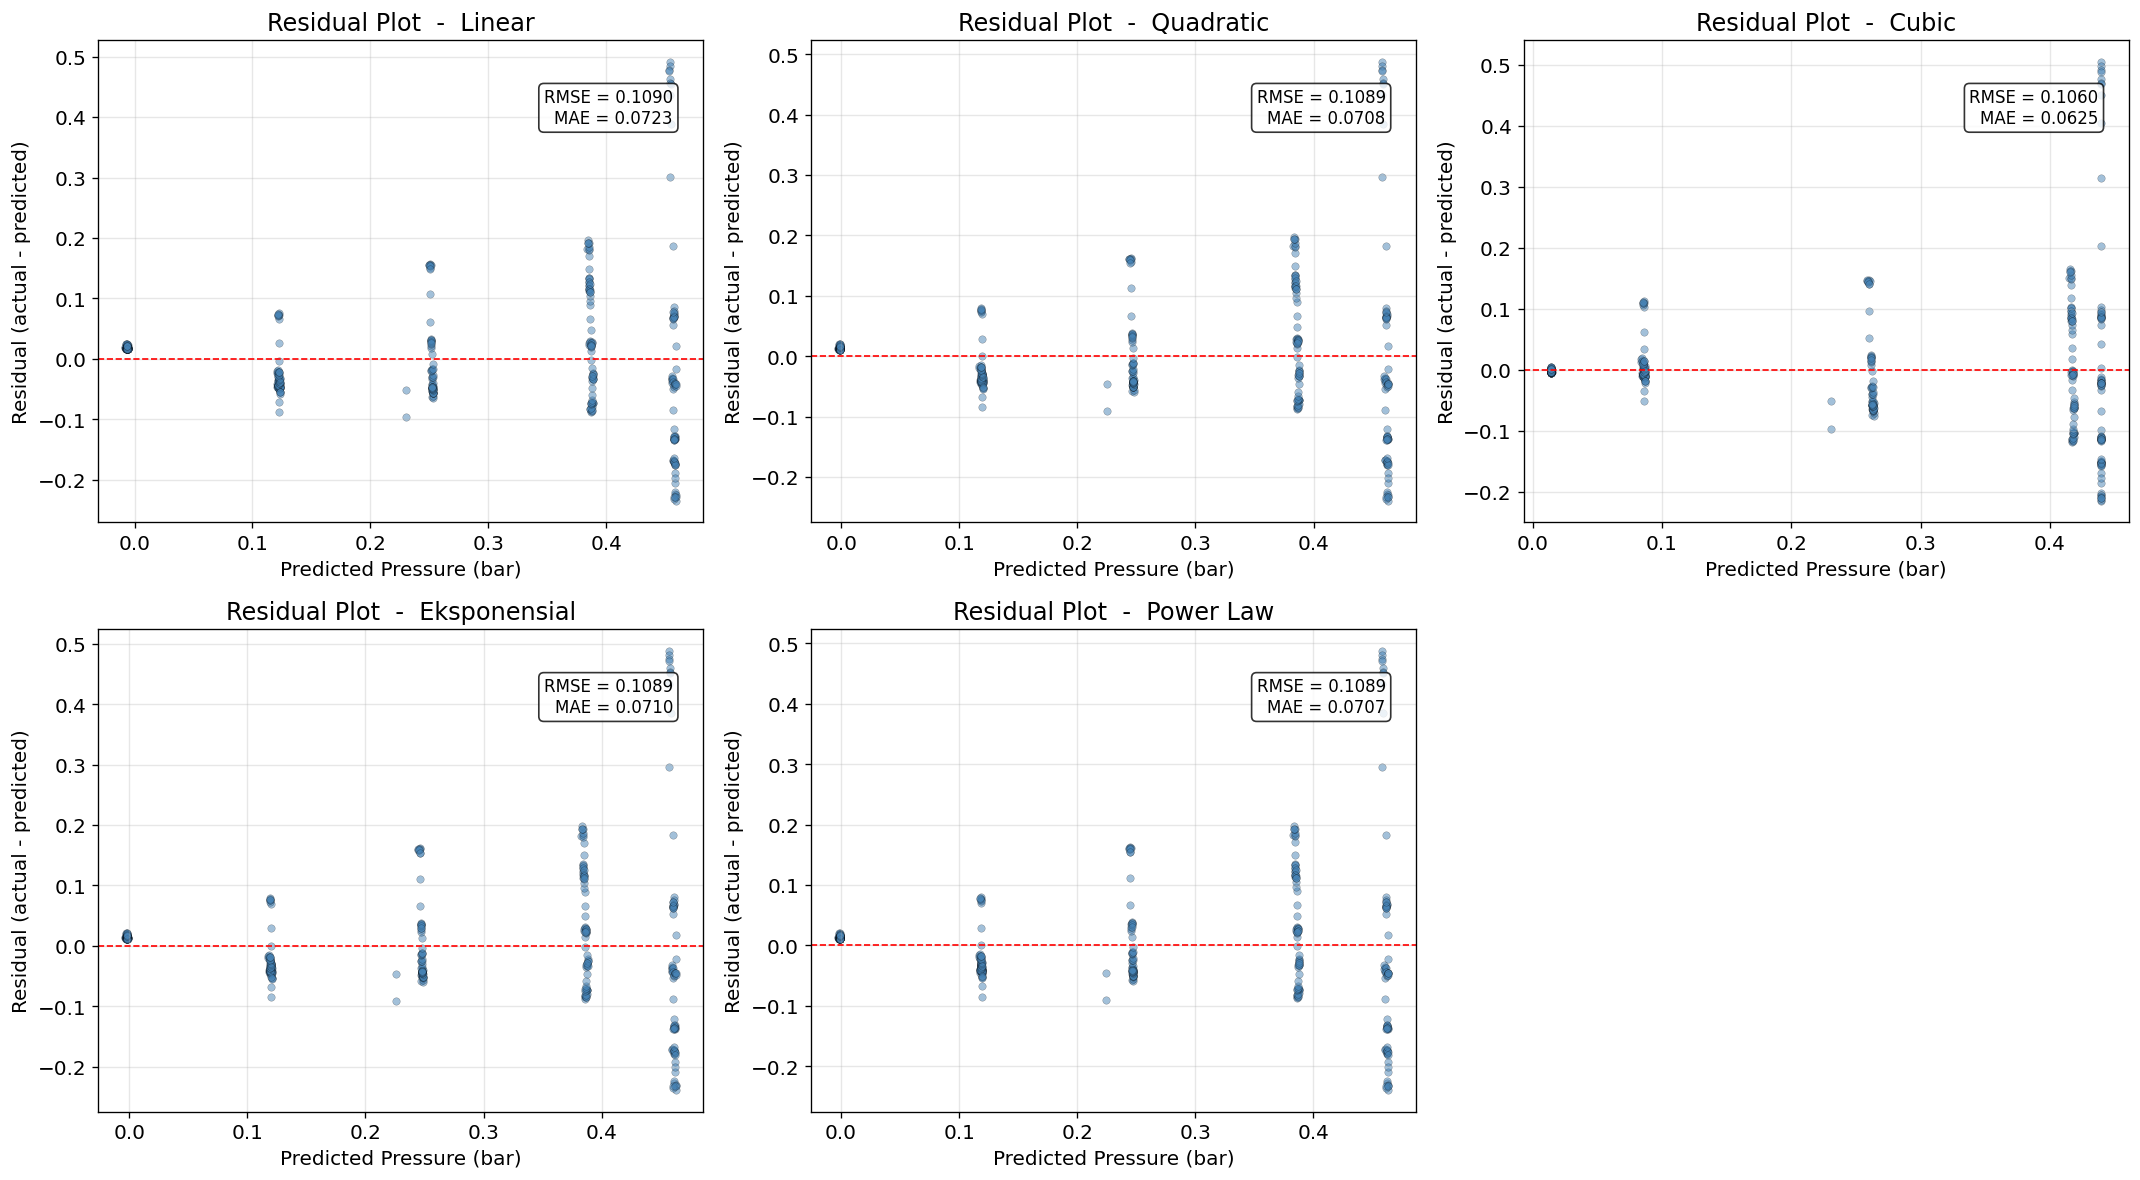

Gambar disimpan di: analisis/residual_plots.png


In [7]:
fig, axes = plt.subplots(rows2, cols2, figsize=(18, 5 * rows2))
axes = axes.flatten()

for i, name in enumerate(model_names):
    ax = axes[i]
    p, y_pred = models[name]
    residuals = y_full - y_pred
    ax.scatter(y_pred, residuals, s=20, alpha=0.5, c="steelblue", edgecolors="k", linewidth=0.2)
    ax.axhline(y=0, color="red", linestyle="--", linewidth=1)
    ax.set_xlabel("Predicted Pressure (bar)")
    ax.set_ylabel("Residual (actual - predicted)")
    ax.set_title(f"Residual Plot  -  {name}")
    rmse = np.sqrt(mean_squared_error(y_full, y_pred))
    mae = mean_absolute_error(y_full, y_pred)
    ax.text(0.95, 0.90, f"RMSE = {rmse:.4f}\nMAE = {mae:.4f}", transform=ax.transAxes, 
            fontsize=10, ha="right", va="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# Hide unused
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(DATA_DIR + "\\analisis\\residual_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gambar disimpan di: analisis/residual_plots.png")

## 8. Visualisasi Tambahan: Hubungan Tiga Variabel (V, P, Duty)

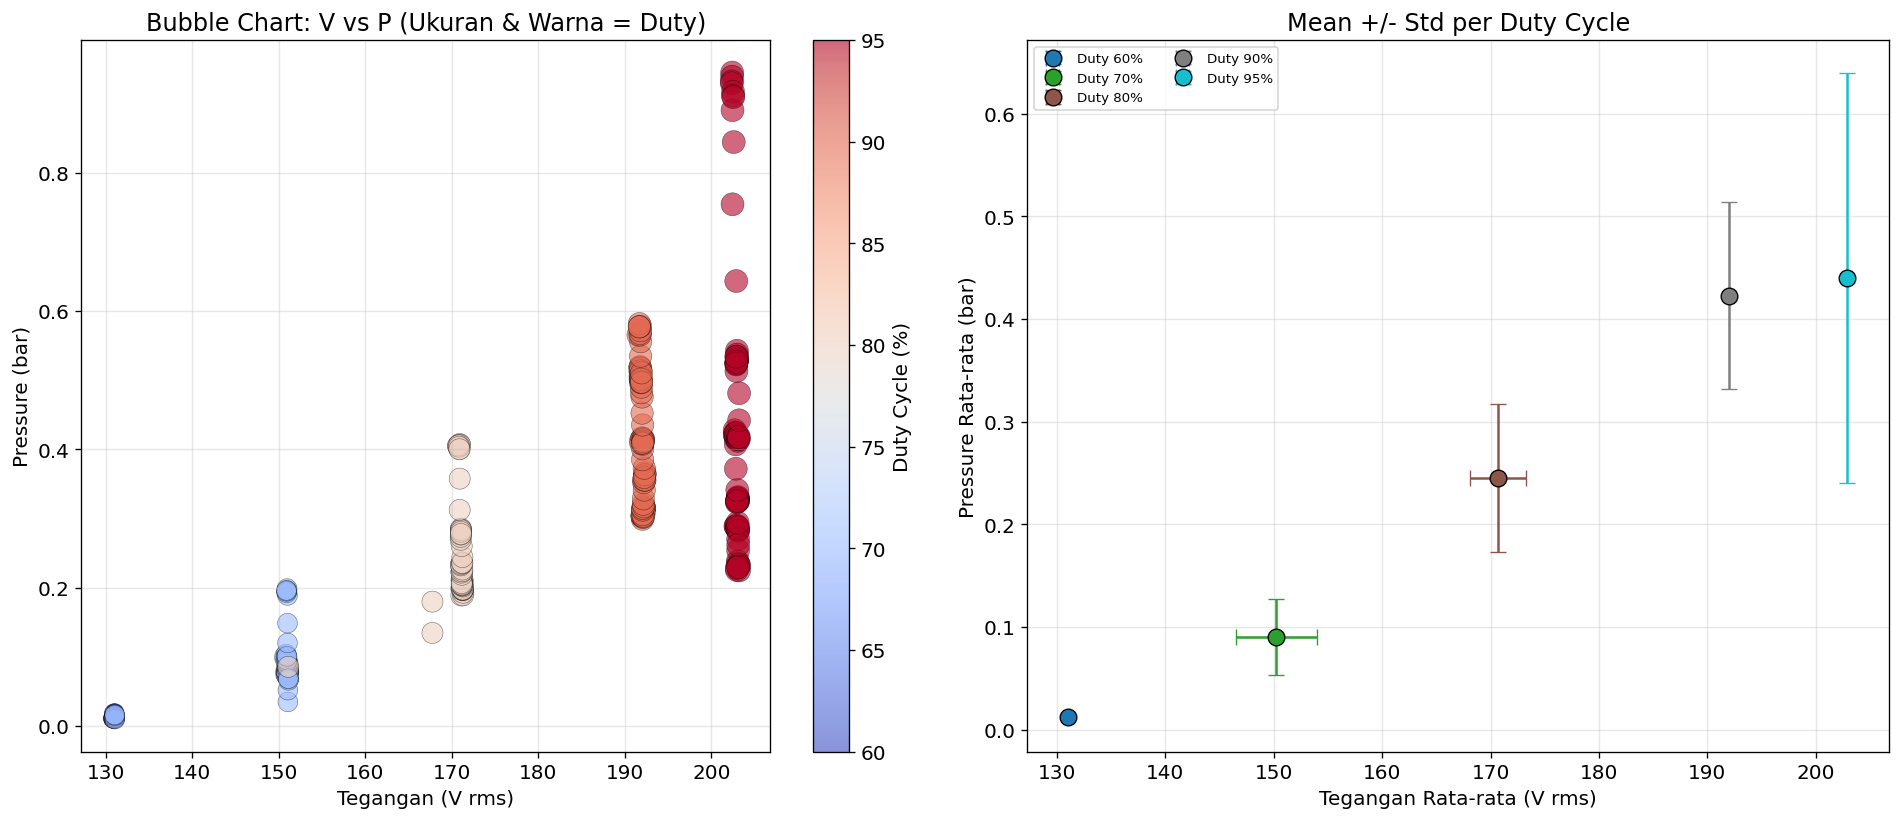

Gambar disimpan di: analisis/bubble_and_errorbar.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Bubble chart: size = duty
ax = axes[0]
bubble = ax.scatter(df["jsy_voltage_rms_v"], df["pressure_bar"],
                     s=df["duty_percent"]*2, c=df["duty_percent"],
                     cmap="coolwarm", alpha=0.6, edgecolors="k", linewidth=0.3)
cbar = plt.colorbar(bubble, ax=ax)
cbar.set_label("Duty Cycle (%)")
ax.set_xlabel("Tegangan (V rms)")
ax.set_ylabel("Pressure (bar)")
ax.set_title("Bubble Chart: V vs P (Ukuran & Warna = Duty)")

# Mean per duty + error bars
ax = axes[1]
for i, duty in enumerate(duties):
    sub = df[df["duty_percent"] == duty]
    v_mean = sub["jsy_voltage_rms_v"].mean()
    p_mean = sub["pressure_bar"].mean()
    v_std = sub["jsy_voltage_rms_v"].std()
    p_std = sub["pressure_bar"].std()
    ax.errorbar(v_mean, p_mean, xerr=v_std, yerr=p_std,
               fmt="o", capsize=5, capthick=1.5, markersize=10,
               color=colors[i], label=f"Duty {duty}%", markeredgecolor="k", markeredgewidth=0.8)

ax.set_xlabel("Tegangan Rata-rata (V rms)")
ax.set_ylabel("Pressure Rata-rata (bar)")
ax.set_title("Mean +/- Std per Duty Cycle")
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(DATA_DIR + "\\analisis\\bubble_and_errorbar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gambar disimpan di: analisis/bubble_and_errorbar.png")

## 9. Box Plot: Distribusi Pressure dan Tegangan Per Duty Cycle

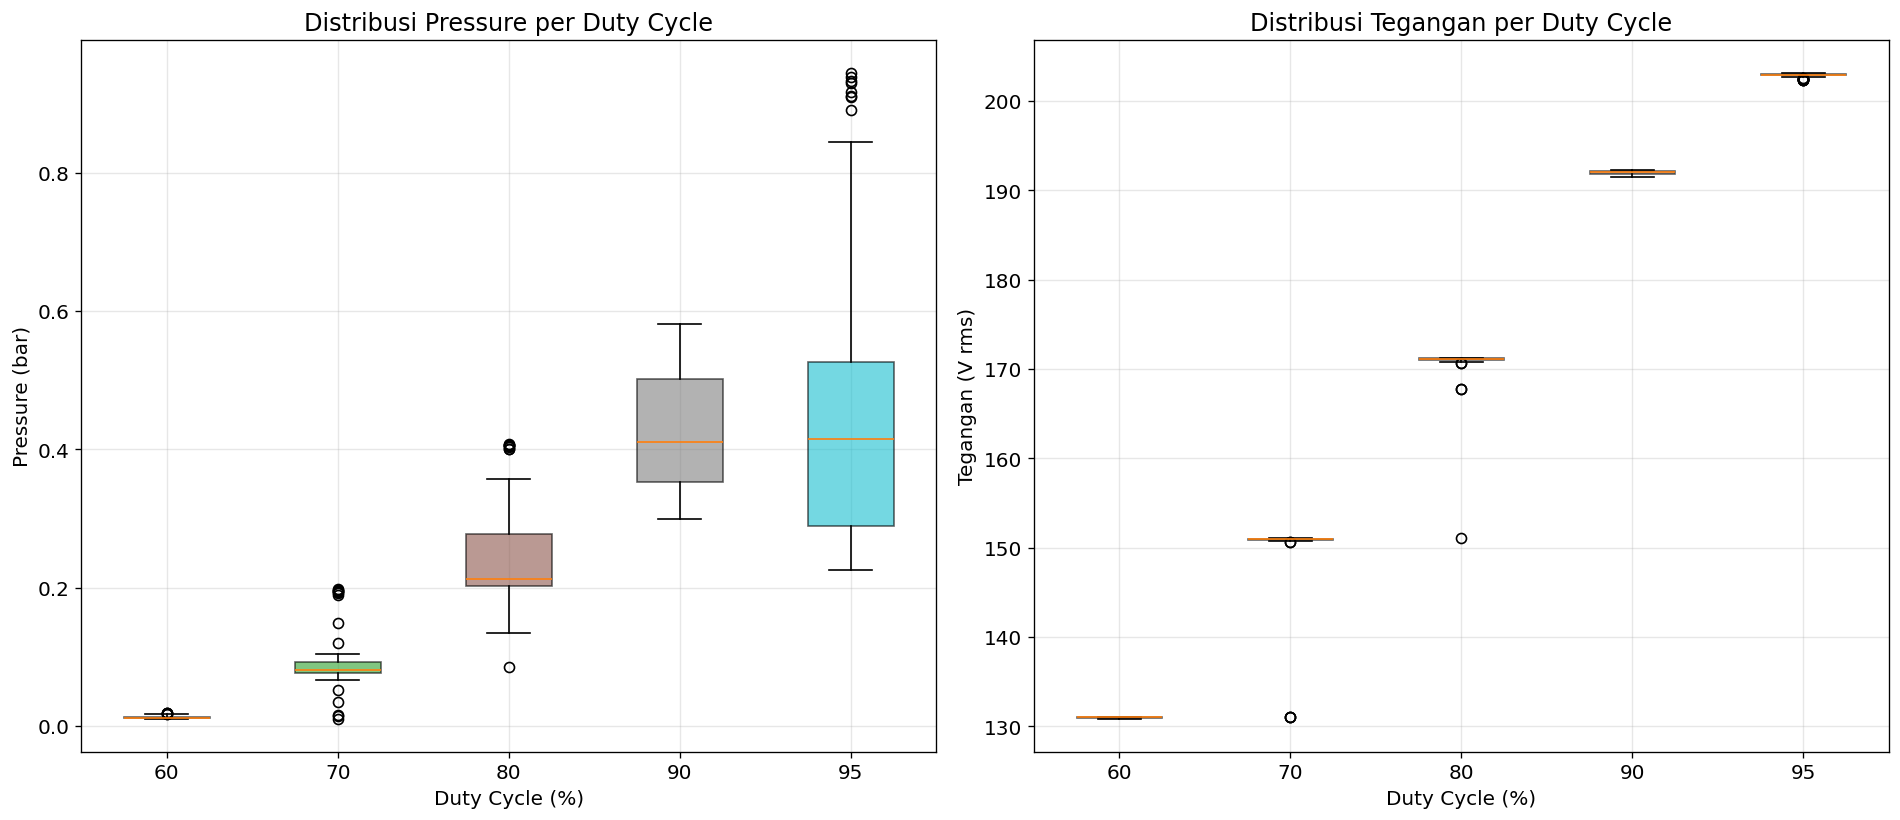

Gambar disimpan di: analisis/boxplot_per_duty.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Box plot per duty - pressure
duty_groups = [df[df["duty_percent"] == d]["pressure_bar"] for d in duties]
bp = axes[0].boxplot(duty_groups, labels=duties, patch_artist=True)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)
axes[0].set_xlabel("Duty Cycle (%)")
axes[0].set_ylabel("Pressure (bar)")
axes[0].set_title("Distribusi Pressure per Duty Cycle")

# Box plot per duty - tegangan
v_groups = [df[df["duty_percent"] == d]["jsy_voltage_rms_v"] for d in duties]
bp2 = axes[1].boxplot(v_groups, labels=duties, patch_artist=True)
for patch, c in zip(bp2["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.6)
axes[1].set_xlabel("Duty Cycle (%)")
axes[1].set_ylabel("Tegangan (V rms)")
axes[1].set_title("Distribusi Tegangan per Duty Cycle")

plt.tight_layout()
plt.savefig(DATA_DIR + "\\analisis\\boxplot_per_duty.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gambar disimpan di: analisis/boxplot_per_duty.png")

## 10. Regresi Linear Per Duty Cycle

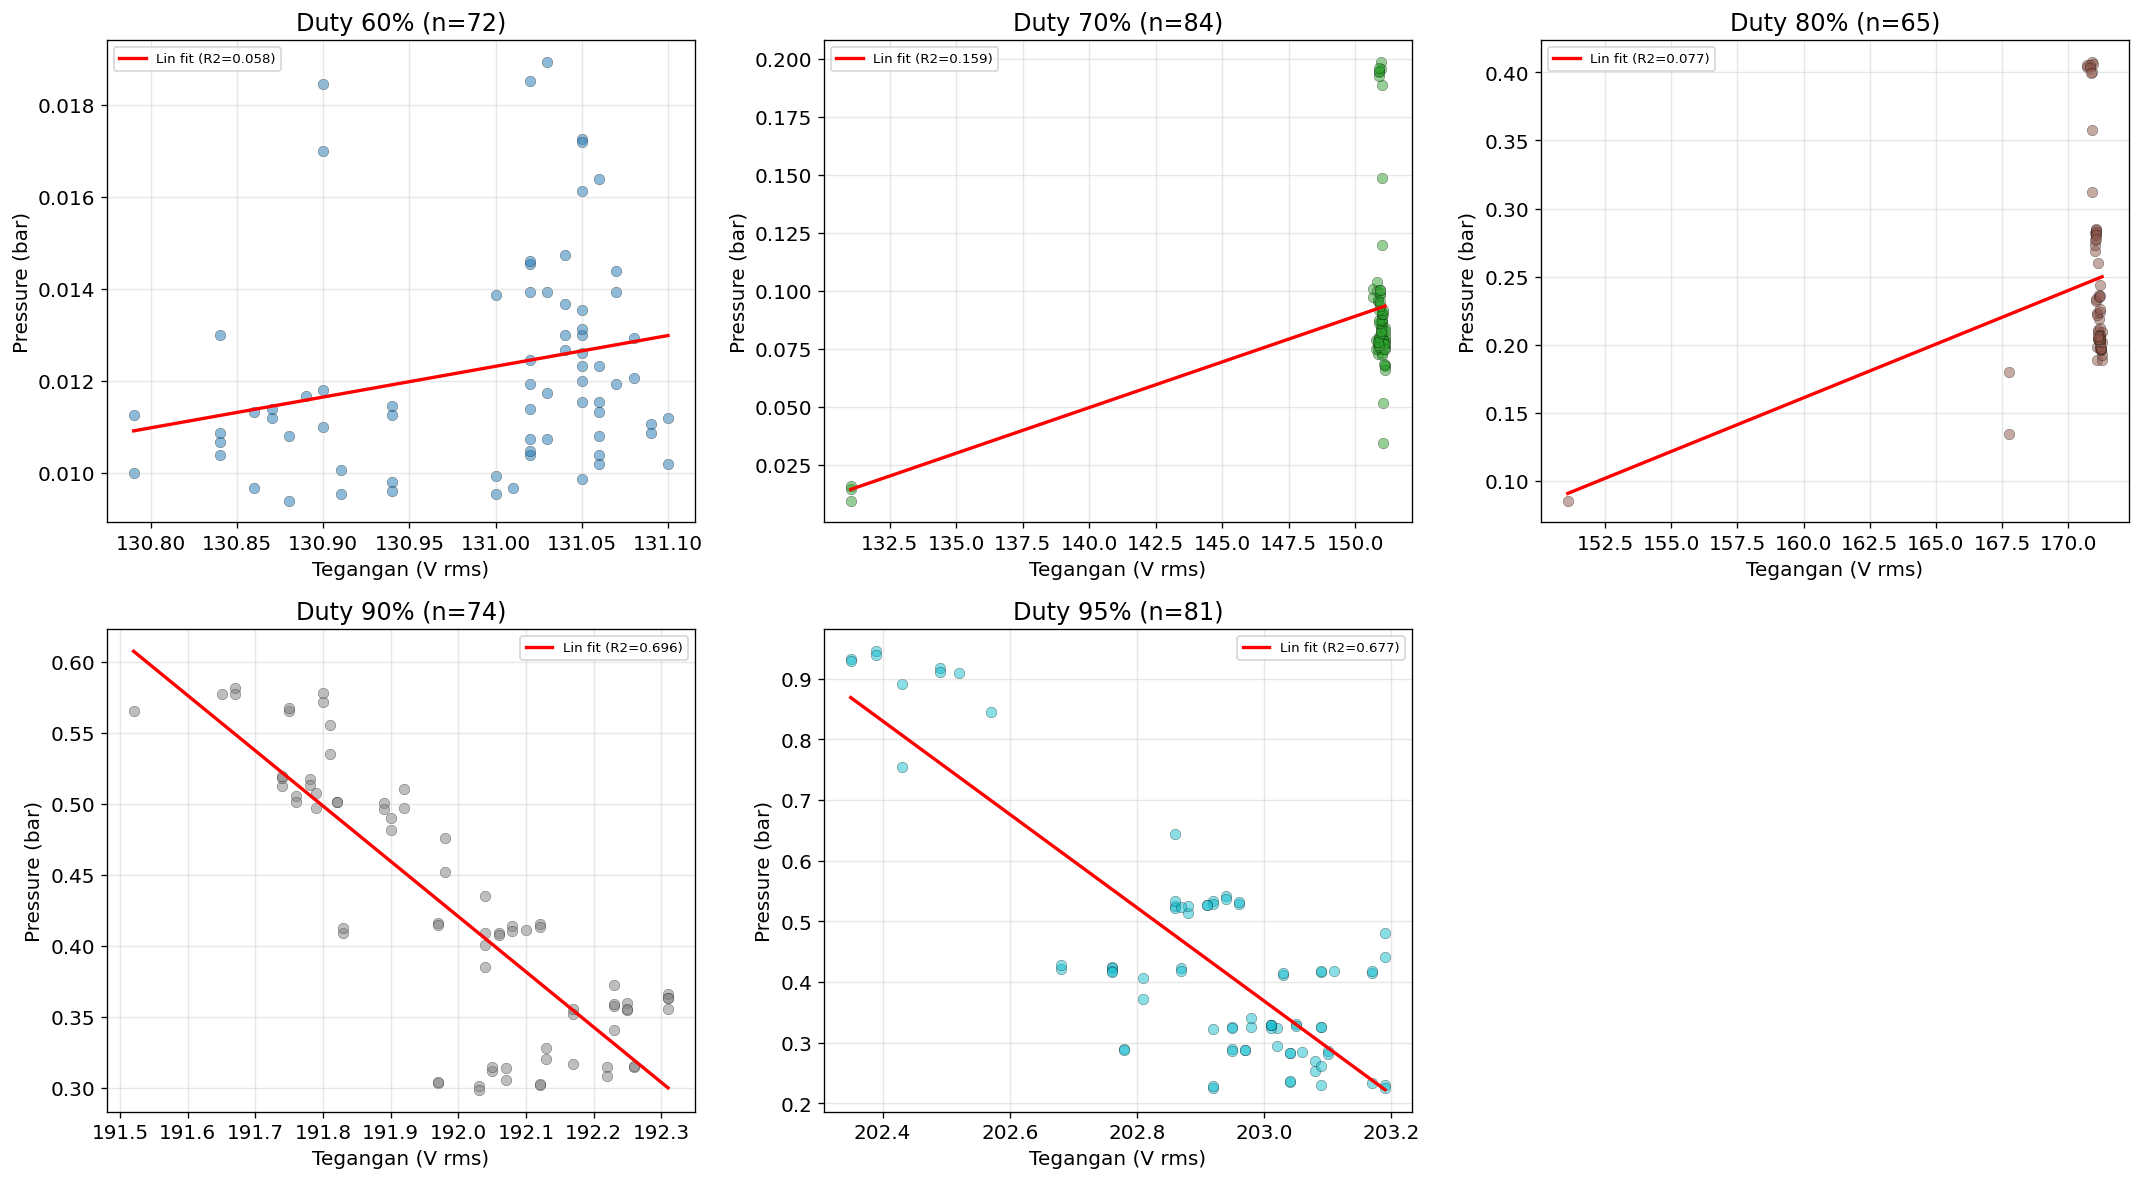


=== REGRESI LINEAR PER DUTY CYCLE ===
 Duty  n     R2  Slope_a  Intercept_b   V_mean  P_mean
   60 72 0.0579   0.0067      -0.8639 130.9922  0.0123
   70 84 0.1589   0.0039      -0.5004 150.2520  0.0901
   80 65 0.0769   0.0079      -1.1014 170.6906  0.2452
   90 74 0.6965  -0.3887      75.0476 191.9950  0.4226
   95 81 0.6765  -0.7692     156.5205 202.9069  0.4402


In [10]:
# Regresi linear per duty cycle
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

per_duty_results = []

for i, duty in enumerate(duties):
    sub = df[df["duty_percent"] == duty]
    X_sub = sub["jsy_voltage_rms_v"].values
    y_sub = sub["pressure_bar"].values
    
    if len(X_sub) > 2:
        p_sub, _ = curve_fit(linear, X_sub, y_sub, maxfev=10000)
        y_sub_pred = linear(X_sub, *p_sub)
        r2_sub = r2_score(y_sub, y_sub_pred)
        
        ax = axes[i]
        ax.scatter(X_sub, y_sub, s=40, alpha=0.5, c=colors[i], edgecolors="k", linewidth=0.3)
        X_sort = np.linspace(X_sub.min(), X_sub.max(), 100)
        ax.plot(X_sort, linear(X_sort, *p_sub), "r-", linewidth=2, label=f"Lin fit (R2={r2_sub:.3f})")
        ax.set_title(f"Duty {duty}% (n={len(sub)})")
        ax.set_xlabel("Tegangan (V rms)")
        ax.set_ylabel("Pressure (bar)")
        ax.legend(fontsize=8)
        
        per_duty_results.append({
            "Duty": duty, "n": len(sub), "R2": r2_sub,
            "Slope_a": p_sub[0], "Intercept_b": p_sub[1],
            "V_mean": X_sub.mean(), "P_mean": y_sub.mean()
        })

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(DATA_DIR + "\\analisis\\regresi_per_duty.png", dpi=150, bbox_inches="tight")
plt.show()

# Tabel hasil per duty
df_perduty = pd.DataFrame(per_duty_results).round(4)
print("\n=== REGRESI LINEAR PER DUTY CYCLE ===")
print(df_perduty.to_string(index=False))

## 11. Kesimpulan

In [11]:
# Ringkasan hasil
print("=" * 70)
print("                    KESIMPULAN ANALISIS")
print()
print("Hubungan Tegangan Input vs Pressure Pompa Air")
print("Kondisi: 4 keran bukaan setengah, duty >= 60%, fase stabil")
print("=" * 70)
print()
print("Perbandingan R2 Model:")
for _, row in df_results.iterrows():
    bar = "#" * int(row["R2"] * 50)
    print(f"  {row['Model']:45s}  R2 = {row['R2']:.4f}  RMSE = {row['RMSE']:.4f}  {bar}")

print()
best_model = df_results.iloc[0]
print(f"Model terbaik: {best_model['Model']}")
print(f"  R2 = {best_model['R2']:.4f}")
print(f"  RMSE = {best_model['RMSE']:.4f}")
print(f"  Parameter: {best_model['Params']}")
print()

# Interpretasi
if r2_lin > 0.9:
    print("-> Hubungan tegangan-pressure bersifat LINEAR KUAT (R2 > 0.9).")
    print(f"   Setiap kenaikan tegangan 1V menaikkan pressure sekitar {p_lin[0]:.4f} bar.")
elif r2_lin > 0.7:
    print(f"-> Hubungan tegangan-pressure CENDERUNG LINEAR (R2 linear = {r2_lin:.4f}).")
else:
    print(f"-> Hubungan BUKAN linear murni (R2 linear = {r2_lin:.4f}).")
    if 'r2_quad' in dir() and (r2_quad - r2_lin) > 0.05:
        print("   Model kuadratik/polinomial lebih cocok - ada sedikit kurva.")
    if r2_exp > r2_lin + 0.05:
        print("   Model eksponensial lebih cocok - response nonlinear.")

print()
print("Semua grafik disimpan di folder: analisis/")
print("File output:")
print("  - scatter_tegangan_vs_pressure.png")
print("  - scatter_per_duty.png")
print("  - regression_comparison.png")
print("  - residual_plots.png")
print("  - bubble_and_errorbar.png")
print("  - boxplot_per_duty.png")
print("  - regresi_per_duty.png")

                    KESIMPULAN ANALISIS

Hubungan Tegangan Input vs Pressure Pompa Air
Kondisi: 4 keran bukaan setengah, duty >= 60%, fase stabil

Perbandingan R2 Model:
  Cubic: P = a*V^3 + b*V^2 + c*V + d             R2 = 0.7289  RMSE = 0.1060  ####################################
  Power: P = a*V^b + c                           R2 = 0.7139  RMSE = 0.1089  ###################################
  Quadratic: P = a*V^2 + b*V + c                 R2 = 0.7138  RMSE = 0.1089  ###################################
  Eksponensial: P = a*e^(b*V) + c                R2 = 0.7137  RMSE = 0.1089  ###################################
  Linear: P = a*V + b                            R2 = 0.7134  RMSE = 0.1090  ###################################

Model terbaik: Cubic: P = a*V^3 + b*V^2 + c*V + d
  R2 = 0.7289
  RMSE = 0.1060
  Parameter: a=-0.000003, b=0.001327, c=-0.212652, d=11.042749

-> Hubungan tegangan-pressure CENDERUNG LINEAR (R2 linear = 0.7134).

Semua grafik disimpan di folder: analisis/
File o